# Ecommerce Dashboard (HDFS)

Dashboard cho kết quả MapReduce bài toán ecommerce.

In [1]:
!pip install hdfs pyspark==3.5.1 pandas matplotlib --break-system-packages

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 3.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 4.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 4.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 4.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 3.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 3.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 4.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[

In [2]:
from hdfs import InsecureClient

client = InsecureClient("http://namenode:9870", user="root")
client.list("/user/airflow/ecommerce_analysis")

['a_businessman_300k_car_phone', 'b_age_groups', 'b_age_groups_csv']

In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("ecommerce-dashboard")
    .master("spark://spark-master:7077")
    .getOrCreate()
)

path_a = "hdfs://namenode:8020/user/airflow/ecommerce_analysis/a_businessman_300k_car_phone"
path_b = "hdfs://namenode:8020/user/airflow/ecommerce_analysis/b_age_groups"

df_a = spark.read.parquet(path_a)
df_b = spark.read.parquet(path_b)

print("So khach hang thoa dieu kien a):", df_a.count())
df_a.show(20, truncate=False)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/04 09:24:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

So khach hang thoa dieu kien a): 174
+---+-----------------+---+-----------+------+--------+------------+
|id |name             |age|occupation |income|owns_car|phone_number|
+---+-----------------+---+-----------+------+--------+------------+
|21 |Sophia Anderson  |32 |businessman|376541|yes     |0939744101  |
|34 |Henry Clark      |45 |businessman|319752|yes     |0921963091  |
|70 |Olivia Taylor    |35 |businessman|319549|yes     |0942009949  |
|82 |John Miller      |60 |businessman|385792|yes     |0993334906  |
|169|Michael Garcia   |20 |businessman|391171|yes     |0959350031  |
|201|Amelia Anderson  |64 |businessman|350892|yes     |0997417729  |
|246|Matthew Smith    |39 |businessman|313111|yes     |0928963180  |
|336|Mia Brown        |32 |businessman|304454|yes     |0937095581  |
|377|Olivia Anderson  |60 |businessman|339840|yes     |0941646483  |
|461|Daniel Moore     |22 |businessman|379984|yes     |0933313203  |
|516|Emily Thompson   |33 |businessman|387325|yes     |0926217876 

,age_group,customer_count
0,<30,1104
1,"[30,45)",1733
2,"[45,60)",1656
3,>=60,1907


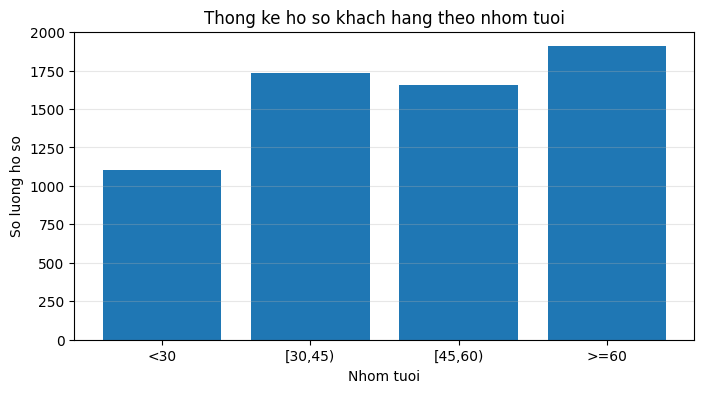

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

pdf_b = df_b.toPandas()
order = {"<30": 1, "[30,45)": 2, "[45,60)": 3, ">=60": 4}
pdf_b["sort_key"] = pdf_b["age_group"].map(order)
pdf_b = pdf_b.sort_values("sort_key").drop(columns=["sort_key"])

display(pdf_b)

plt.figure(figsize=(8, 4))
plt.bar(pdf_b["age_group"], pdf_b["customer_count"])
plt.title("Thong ke ho so khach hang theo nhom tuoi")
plt.xlabel("Nhom tuoi")
plt.ylabel("So luong ho so")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [5]:
spark.stop()